# **LA RHÉTORIQUE DE GUERRE DANS LES DISCOURS PRÉSIDENTIELS FRANCAIS DEPUIS LE 11 SEPTEMBRE 2001**

## **Introduction**

**Résumé :** Depuis la pandémie de 2020, les discours présidentiels français semblent avoir de plus en plus recours au lexique de la guerre. Ce projet de recherche détaillé a pour objectif d’explorer la rhétorique guerrière dans les discours présidentiels français dans le temps long à l’aide des méthodes computationnelles. À cette fin, une étude sur un corpus initial de 5 554 discours datant de 2001 à 2025 a été réalisée. Elle prouve l’importance de la guerre dans les discours présidentiels de manière générale, mais aussi l’importance croissante de son vocabulaire avec le temps. La cooccurrence de la guerre avec d’autres thématiques se distingue comme un phénomène marquant depuis 2017-2018. Ces résultats justifient la poursuite du travail dans le cadre d’un projet à part entière, et appellent l’utilisation de méthodes plus avancées comme l’analyse de réseau.

**Mots-clés :** analyse de discours, rhétorique guerrière, traitement automatique du langage, Président de la République française, 2001-2025

Notre question initiale porte sur le tournant sémantique supposé des discours présidentiels français. La guerre semble apparaître davantage, et elle semble de plus en plus associée à des sujets qui lui sont extérieurs (santé, démographie, culture…). Notre cadre analyse vise à expliquer quantitativement ce tournant par la cooccurrence à travers le temps. Cependant, à ce stade de la réflexion, nous ne savons pas si la présence de guerre est bel et bien croissante dans les discours, mais également davantage associée à d’autres thématiques, ni depuis quand. L’enjeu de cette recherche exploratoire sera donc d’objectiver l’évolution de la guerre dans les discours présidentiels français, et de déterminer un tournant, en vue d’un futur mémoire : la guerre est-elle réellement de plus en plus présente dans les discours présidentiels français ? Plusieurs hypothèses s’imposent :

- **Hypothèse 1 (importance générale) :** La guerre est un sujet important dans les discours présidentiels français comparé à d’autres thématiques.
- **Hypothèse 2 (importance croissante) :** La guerre est un sujet qui devient de plus en plus important avec le temps dans les discours présidentiels.
- **Hypothèse 3 (expansion de l’importance) :** La guerre est de plus en plus associée à d’autres thématiques dans les discours.

À nos yeux, une étude approfondie du sujet sera justifiée à partir du moment où ces trois hypothèses se confirment.

In [29]:
## Importation des bibliothèques nécessaires au projet
# Pour la gestion du dataframe
import numpy as np
import pandas as pd

# Pour le TALN (NLP)
import spacy
import nltk

# Spécification concernant SpaCy : utilisation de la langue française
nlp = spacy.load("fr_core_news_sm")

# Pour la gestion des dates en français
import locale
locale.setlocale(locale.LC_ALL, "fr_FR")

# Pour les représentations graphiques
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
sns.set_context("paper")
sns.set_palette("deep")
sns.despine(top=False, right=False, left=False, bottom=False)

# Pour le calcul du TF-IDF
from gensim.models import TfidfModel
from gensim.corpora import Dictionary

# Pour l'analyse statistique
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import kruskal

<Figure size 640x480 with 0 Axes>

## **1-) Base de données**

La première étape consiste à aspirer les données à l'aide d'une extension web externe à Jupyter Notebook : Web Scraper. Le code a été produit via cette extension par des simples clics. La source et le code produits sont fournis dans les cellules ci-dessous. On vérifie ensuite le contenu du Dataframe dans Jupyter Notebook

In [ ]:
# Code utilisé pour aspirer la base de donnée (créer et utilisé via web-scraper, application web)
'''
Source :  https://www.vie-publique.fr/discours/recherche?search_api_fulltext_discours=&sort_by=field_date_prononciation_discour&field_intervenant_title=&field_intervenant_qualite=&field_date_prononciation_discour_interval%5Bmin%5D=2001-09-10&field_date_prononciation_discour_interval%5Bmax%5D=2026-01-01&field_type_emetteur%5B9340%5D=9340
Code :  {"_id":"analyse-discours-presidentiels","startUrl":["https://www.vie-publique.fr/discours/recherche?search_api_fulltext_discours=&sort_by=field_date_prononciation_discour&field_intervenant_title=&field_intervenant_qualite=&field_date_prononciation_discour_interval%5Bmin%5D=2001-09-10&field_date_prononciation_discour_interval%5Bmax%5D=2026-01-01&field_type_emetteur%5B9340%5D=9340"],"selectors":[{"id":"discours-individuels","parentSelectors":["pages"],"type":"SelectorLink","selector":".fr-card__title a","multiple":true,"linkType":"linkFromHref"},{"id":"titre","parentSelectors":["discours-individuels"],"type":"SelectorText","selector":"h1","multiple":false,"regex":""},{"id":"thématique","parentSelectors":["discours-individuels"],"type":"SelectorText","selector":".vp-page-thematic a","multiple":false,"regex":""},{"id":"détails","parentSelectors":["discours-individuels"],"type":"SelectorText","selector":"time","multiple":false,"regex":""},{"id":"intervenant","parentSelectors":["discours-individuels"],"type":"SelectorText","selector":".line-intervenant a","multiple":false,"regex":""},{"id":"corps","parentSelectors":["discours-individuels"],"type":"SelectorText","selector":".field--name-field-texte-integral, .field--type-text-long","multiple":false,"regex":""},{"id":"mots-cles","parentSelectors":["discours-individuels"],"type":"SelectorText","selector":".vp-tags a","multiple":false,"regex":""},{"id":"pages","parentSelectors":["_root","pages"],"paginationType":"auto","type":"SelectorPagination","selector":"a.vp-pagination--link-number[title]"}]}
'''

In [3]:
# Importation des données et vérification des variables
df = pd.read_csv("C:/Users/.../analyse-discours-presidentiels.csv")
print(df.head())

  web-scraper-order                              web-scraper-start-url  \
0      1768752907-1  https://www.vie-publique.fr/discours/recherche...   
1      1768752909-2  https://www.vie-publique.fr/discours/recherche...   
2      1768752912-3  https://www.vie-publique.fr/discours/recherche...   
3      1768752915-4  https://www.vie-publique.fr/discours/recherche...   
4      1768752921-5  https://www.vie-publique.fr/discours/recherche...   

                                discours-individuels  \
0  Discours de M. Jacques Chirac, Président de la...   
1  Discours de M. Jacques Chirac, Président de la...   
2  Intervention de M. Jacques Chirac, Président d...   
3  Intervention télévisée de M. Jacques Chirac, P...   
4  Lettre de M. Jacques Chirac, Président de la R...   

                           discours-individuels-href  \
0  https://www.vie-publique.fr/discours/195774-di...   
1  https://www.vie-publique.fr/discours/194083-di...   
2  https://www.vie-publique.fr/discours/196432-in.

## **2-) Nettoyage de la base de données**

La deuxième étape consiste à vérifier l'existence de données manquantes. Les données manquantes sont supprimées de la base de données. On trie ensuite les intervenants pour conserver uniquement les Présidents de la République. Enfin, les dates textuelles sont transformées en données numériques pouvant être reconnues par Python.

In [4]:
# Vérification des données manquantes pour les corps de texte
print(f"Nombre de valeurs manquantes : {df["corps"].isna().sum()}")
print(f"Type de données : {df["corps"].dtype}")
# Suppression des données manquantes
df["corps"] = df["corps"].fillna("")
df["corps"] = df["corps"].astype(str)
print(f"Nombre de valeurs manquantes après nettoyage : {df["corps"].isna().sum()}")

Nombre de valeurs manquantes : 3
Type de données : object
Nombre de valeurs manquantes après nettoyage : 0


In [5]:
# Vérification des données manquantes pour les intervenants
print(f"Nombre de valeurs manquantes : {df["intervenant"].isna().sum()}")
print(f"Type de données : {df["intervenant"].dtype}")
# Suppression des données manquantes
df["intervenant"] = df["intervenant"].fillna("")
df["intervenant"] = df["intervenant"].astype(str)
print(f"Nombre de valeurs manquantes après nettoyage : {df["intervenant"].isna().sum()}")

Nombre de valeurs manquantes : 7
Type de données : object
Nombre de valeurs manquantes après nettoyage : 0


In [6]:
# Vérification des données manquantes pour les dates
print(f"Nombre de valeurs manquantes : {df["détails"].isna().sum()}")
print(f"Type de données : {df["détails"].dtype}")
# Suppression des données manquantes
df["détails"] = df["détails"].fillna("")
df["détails"] = df["détails"].astype(str)
print(f"Nombre de valeurs manquantes après nettoyage : {df["détails"].isna().sum()}")

Nombre de valeurs manquantes : 155
Type de données : object
Nombre de valeurs manquantes après nettoyage : 0


In [8]:
# Suppression des intervenants hors présidents
présidents = ["François Hollande", "Jacques Chirac", "Emmanuel Macron", "Nicolas Sarkozy"]
df = df[df["intervenant"].isin(présidents)]
df["intervenant"].value_counts()

intervenant
François Hollande    1628
Jacques Chirac       1434
Emmanuel Macron      1269
Nicolas Sarkozy      1193
Name: count, dtype: int64

In [94]:
# Création d'une variable date utilisable
df["date"] = pd.to_datetime(df["détails"], format="%d %B %Y", dayfirst=True)
df["date"].head()
df["année"] = df["date"].dt.year

In [15]:
# Gestion des valeurs manquates
print(f"Nombre de valeurs manquantes : {df["date"].isna().sum()}")
print(f"Type de données : {df["date"].dtype}")
df["date"] = df["date"].dropna()
print(f"Nombre de valeurs manquantes après nettoyage : {df["date"].isna().sum()}")

Nombre de valeurs manquantes : 154
Type de données : datetime64[ns]
Nombre de valeurs manquantes après nettoyage : 0


## **3-) Normalisation du texte**

La troisième étape consiste à normaliser le texte. Les bibliothèques SpaCy et NLTK ont été utilisées. Le code est issu des livres « Python pour les SHS » d'Émilien Schultz et Mathias Bussonnier, ainsi que de  « Traitement automatique du langage naturel avec Python » de Benoit Prieur. Le texte est d'abord mis en minuscules. Les mots vides comme « le », « du » ou « mes » ainsi que la ponctuation ont été retirés. Le texte a ensuite été tokenisé (les mots ont été isolés les uns des autres). Les mots restants ont été lemmatisés, c’est-à-dire que le pluriel et le féminin ont été transformés en forme dites « neutres ». Le corpus n’a pas fait l’objet de racinisation, qui aurait permit de rendre le traitement du texte plus rapide et d’uniformiser davantage certains mots proches les uns des autres. Ce rejet s’explique par l’ambiguïté intellectuelle de la racinisation à notre niveau d’apprentissage de la programmation. L’analyse des données aurait été plus complexe et aurait nécessité un encadrement formel par un enseignant spécialisé.

Il existe deux versions du texte nettoyé : la version « string » et la version « tokens ». La première est utilisée pour parcourir rapidement le contenu d'un discours pendant la programmation, la deuxième sera utilisée pour compter formellement les occurrences pour 10 000 mots, le TF-IDF et la cooccurrence.

In [ ]:
# Ajout de stopwords supplémentaires à retirer du corpus
stops = nlp.Defaults.stop_words
nlp.Defaults.stop_words.add(".")
nlp.Defaults.stop_words.add(",")
nlp.Defaults.stop_words.add("-")
nlp.Defaults.stop_words.add(";")
nlp.Defaults.stop_words.add(":")
nlp.Defaults.stop_words.add(":")
nlp.Defaults.stop_words.add("*")

In [ ]:
# Algorithme de normalisation : minuscules, tokenisation, lemmatisation et suppression des stopwords
def normalisation(token, lowercase, remove_stopwords):
    if lowercase:
        token = token.lower()
    token = nlp(token)
    lemmatisation = list()
    for word in token:
        lemme = word.lemma_.strip()
        if lemme:
            if not remove_stopwords or (remove_stopwords and lemme not in stops):
                lemmatisation.append(lemme)
    return " ".join(lemmatisation)

In [ ]:
# Normalisation du corpus
# /!\ ATTENTION PROCEDURE LONGUE (~30min-1h) /!\
df["corpus-nettoyé"] = df["corps"].apply(normalisation, lowercase=True, remove_stopwords=True)

In [38]:
print(df["corpus-nettoyé"].head())

0    Monsieur maire saint-brieuc cher ami Monsieur ...
1    Monsieur président lemetayer Monsieur ministre...
2    Monsieur président madame monsieur venir ici g...
3    cher compatriote attentat frapper aujourd'hui ...
4    Monsieur président immense émotion france appr...
Name: corpus-nettoyé, dtype: object


In [39]:
# Test sur un discours spécifique
discours_n5431 = df.loc[5430, "corpus-nettoyé"]
print(discours_n5431)

bonjour madame monsieur présence issue édition sommet communauté politique européen vouloir chose remercier ministre edi ramer organisation sommet venir achever démontrer fois utilité format inédit réunion permettre aborder question sécurité traverser europe évidemment discussion utile situation ukraine autour président zelensky lendemain discussion lieu turquie ailleurs arrêt discussion matin.nous savoir suffisamment répéter joue ukraine propre sécurité continuer soutenir cessez-le-feu inconditionnel 30 jour préparer paix robuste durable occasion échanger président zelensky ensuite chancelier merz ministre starmer ministre tusk savez appeler ensemble président trump coordonner réponse fond choix faire russe part appliquer cessez-le-feu part refuser discussion bilatéral russo ukrainien haut niveau réponse positif président zelensky.dans prochain heure délégation ukrainien attendre demande délégation russe occasion rééchanger président trump clair aujourd'hui actualité proposition concr

In [52]:
# Séparation en deux catégories : strings (pour parcourir un discours) et tokens (pour réaliser des opérations)
df["corpus-nettoyé"] = df["corpus-nettoyé"].astype(str)
df["corpus-tokens"] = df["corpus-nettoyé"].apply(lambda x: x.split())

In [40]:
df["corpus-nettoyé"].head()

0    Monsieur maire saint-brieuc cher ami Monsieur ...
1    Monsieur président lemetayer Monsieur ministre...
2    Monsieur président madame monsieur venir ici g...
3    cher compatriote attentat frapper aujourd'hui ...
4    Monsieur président immense émotion france appr...
Name: corpus-nettoyé, dtype: object

In [41]:
df["corpus-tokens"].head()

0    [Monsieur, maire, saint-brieuc, cher, ami, Mon...
1    [Monsieur, président, lemetayer, Monsieur, min...
2    [Monsieur, président, madame, monsieur, venir,...
3    [cher, compatriote, attentat, frapper, aujourd...
4    [Monsieur, président, immense, émotion, france...
Name: corpus-tokens, dtype: object

In [37]:
# Sauvegarde du texte nettoyé, exportation au format CSV afin de ne pas avoir à reprocéder au nettoyage
df.to_csv("C:/Users/.../analyse-discours-presidentiels-nettoyes.csv")

## **4-) Occurrence pour 10 000 mots**

La quatrième étape consiste à compter l'occurrence pour 10 000 mots de différents lexiques thématiques. L'algorithme de comptage permet de sélectionner un mot au choix et d'inscrire son occurrence pour 10 000 mots dans un dictionnaire. La dernière cellule permet d'exporter ses résultats au format CSV. Ainsi, on peut librement constituer ses lexiques au fil de la recherche. Il suffit de revenir à la première cellule pour analyser une nouvelle thématique.

Les 9 thématiques sélectionnées pour l’analyse sont la santé, la démographie, le social, l’économie, la culture, l’environnement, l’éducation, la technologie et la guerre. Chacune de ces catégories inclut 10 mots jugés représentatifs.

- **Dictionnaire santé :** "santé", "sanitaire", "soin", "soignant", "médecin", "médical" "hygiène", "maladie", "vaccin", "médicament"
- **Dictionnaire démographie :** "démographie", "démographique", "naissance", "natalité", "enfant", "vieillissement", "génération", "fécondité", "mortalité", "population"
- **Dictionnaire social :** "social", "société", "solidarité", "assistance", "famille", "familial", "jeunesse", "retraite", "chômage", "âge"
- **Dictionnaire économique :** "économique", "croissance", "développement", "inflation", "budget", "financement", "investissement", "salaire", "capital", "profit"
- **Dictionnaire culture :** "culture", "culturel", "identité", "identitaire", "valeur", "tradition", "héritage", "civilisation", "histoire", "artistique"
- **Dictionnaire environnement :** "environnement", "nature", "biodiversité", "biosphère", "climat", "climatique", "environnemental", "écologie", "écologique", "naturel"
- **Dictionnaire éducation :** "éducation", "université", "éducationnel", "enseignant", "élève", "professeur", "diplôme", "baccalauréat", "master", "enseignement"
- **Dictionnaire technologie :** "technologie", "technologique", "innovation", "numérique", "spatial", "digital", "robotique", "informatique", "automatisation", "ordinateur"
- **Dictionnaire guerre :** "guerre", "paix", "sécurité", "mobilisation", "réarmement", "armée", "conflit", "mobiliser", "front", "bataille"

In [95]:
df["corpus-tokens"].head()

0    [Monsieur, maire, saint-brieuc, cher, ami, Mon...
1    [Monsieur, président, lemetayer, Monsieur, min...
2    [Monsieur, président, madame, monsieur, venir,...
3    [cher, compatriote, attentat, frapper, aujourd...
4    [Monsieur, président, immense, émotion, france...
Name: corpus-tokens, dtype: object

In [96]:
# Création d'un Dataframe lexical pour une nouvelle thématique
mention_10000 = pd.DataFrame()
# À réutiliser pour chaque création d'un nouveau lexique thématique

In [97]:
# Fonction de comptage de mots choisis
def compter_mot_10000(discours):
    compte = discours.count(mot_choisi)
    longueur = len(discours)
    résultat = (compte / longueur) * 10000
    return résultat

In [116]:
## Cellule à utiliser pour former un lexique thématique, le choix du mot est libre
# Choix d'un mot
print("Choisir un mot à compter")
mot_choisi = input()
print("On a choisi le mot :" + " " + mot_choisi)

# Application au corpus
print("Comptage")
df["compte-10000"] = df["corpus-tokens"].apply(compter_mot_10000)
print("Regroupement")
mention_10000[mot_choisi] = df.groupby("année")["compte-10000"].mean()
print(mention_10000[mot_choisi].mean())
print("Fini")

Choisir un mot à compter


 combat


On a choisi le mot : combat
Comptage
Regroupement
9.823445198941402
Fini


In [117]:
# Pour voir l'état du lexique
print(mention_10000.tail())

           guerre       paix   sécurité  mobilisation  réarmement      armée  \
année                                                                          
2021.0   4.835925   7.007805  15.351814      4.828188    0.018776  10.562304   
2022.0  34.155028  14.385454  19.183707      7.179642    0.147548   9.032407   
2023.0  20.345692  14.130889  19.852503      4.909359    0.615525   7.603077   
2024.0  26.541036  19.604670  29.041067      4.716438    0.362888  12.408360   
2025.0  16.539529  37.537907  35.062234      7.652518    0.192381  16.436660   

         conflit  mobiliser    défense     front  attaquer  bataille  \
année                                                                  
2021.0  2.094687  11.521699  10.431902  0.825601  0.933486  2.807606   
2022.0  5.364811  10.479636  10.895240  1.009119  1.899908  1.739032   
2023.0  4.677102   8.425415  13.143922  1.284972  1.217614  4.644648   
2024.0  6.239865   9.467949  18.746890  2.110808  1.568441  2.983011   
2025.0 

In [ ]:
# Exportation au format CSV
mention_10000.to_csv("C:/Users/.../lexique_thématique_lambda.csv")
# Revenir à la première cellule pour créer un nouveau lexique

## **5-) TF-IDF**

La cinquième étape consiste à analyser le TF-IDF du lexique de la guerre. Issu de l’anglais « term frequency-inverse document frequency », le TF-IDF mesure l’importance d’un terme contenu dans un document, relativement à une collection ou un corpus. Le score varie en fonction du nombre d’occurrence dans un document, rapporté au nombre de mots dans le document, ainsi que de la fréquence d’apparition du terme dans le reste du corpus. Un score élevé traduit à la fois une fréquence élevée dans le ou les documents, mais aussi un caractère saillant vis-à-vis du reste du corpus. Un autre indicateur pertinent aurait pu être le calcul des spécificités de Lafon. Cet indacteur permet lui aussi de quantifier l’importance d’un mot relativement au reste du corpus. Cependant, dans le cadre d’un apprentissage autonome, le TF-IDF s’est révélé comme l’indicateur le plus accessible et le plus enseigné dans les manuels de programmation. En outre, sa capacité à démontrer la saillance d’un mot au sein de larges corpus, fait de cet indicateur un outil adapté pour nos 5 521 discours. Afin d’améliorer l’analyse, nous avons étendu le lexique de la guerre à 20 mots au lieu de 10 : 

- **Nouveau lexique de la guerre :** "guerre", "paix", "sécurité", "mobilisation", "réarmement", "armée", "conflit", "menace", "mobiliser", "défense", "front", "attaquer", "bataille", "attaque", "riposte", "déploiement", "stratégique", "tactique", "combattre", "combat".

L'analyse TF-IDF nécessite de transformer le corpus normalisé en vecteurs. L'algorithme TF-IDF est similaire au précédent, dans le sens ou il permet de choisir un mot et d'inscrire sa valeur TF-IDF au fil des ans dans un Dataframe correspondant.

In [222]:
# Vérification de la colonne "corpus-tokens"
df["corpus-tokens"].head()

0    [Monsieur, maire, saint-brieuc, cher, ami, Mon...
1    [Monsieur, président, lemetayer, Monsieur, min...
2    [Monsieur, président, madame, monsieur, venir,...
3    [cher, compatriote, attentat, frapper, aujourd...
4    [Monsieur, président, immense, émotion, france...
Name: corpus-tokens, dtype: object

In [223]:
# Top 10 des scores TF-IDF par discours (à partir du manuel Python d'Émilien Schultz & Matthias Bussonnier)
dictionnary = Dictionary(df["corpus-tokens"])
corpus_converti = [dictionnary.doc2bow(line)
                  for line in list(df["corpus-tokens"])]
modele_tfidf = TfidfModel(corpus_converti)

vectors = [modele_tfidf[i] for i in corpus_converti]

def top_10(vec, dic):
    serie = pd.Series({dic[i[0]]:i[1] for i in vec})
    return serie.sort_values()[0:10].index

tab = pd.DataFrame([top_10(vec, dictionnary) for vec in vectors],
                   index = df["date"])
tab.head()

,0,1,2,3,4,5,6,7,8,9
date,,,,,,,,,,
2001-09-10,france,faire,grand,français,aller,pays,vouloir,monde,ici,mettre
2001-09-11,monde,beaucoup,donner,moment,jour,venir,remercier,responsabilité,porter,besoin
2001-09-11,vouloir,france,grand,français,aller,bien,Monsieur,fois,falloir,monsieur
2001-09-11,france,pays,pouvoir,vouloir,faire,savoir,aujourd'hui,entrer,français,aller
2001-09-11,france,français,aller,bien,venir,falloir,contre,président,etat,luire


In [224]:
# Fonction de calcul TF-IDF en fonction d'un mot choisi
def score_mot_choisi(vec, dictionnary, mot_choisi):

    # Identification de l'ID du mot choisi
    token_id_mot_choisi = dictionnary.token2id.get(mot_choisi)
    if token_id_mot_choisi is None:
        return 0.0
    # Recherche de l'ID identifié dans les discours
    for token_id_score_vec, score in vec:
        if token_id_score_vec == token_id_mot_choisi:
            return score
    # Sinon 0.0
    return 0.0

In [225]:
# Création d'un Dataframe TF-IDF
score_mots_année = pd.DataFrame()

In [245]:
# Choix d'un mot
print("Choisir un mot à compter")
mot_choisi = input()
print("On a choisi le mot :" + " " + mot_choisi)

# Application de la fonction de calcul "score_mot_choisi" à la liste de vecteurs
print("Calcul du score tf-idf du mot choisi")
score_vec_identifié = [score_mot_choisi(vec, dictionnary, mot_choisi) for vec in vectors]
df["score-mot-choisi"] = score_vec_identifié
print(df["score-mot-choisi"].head())

# Création d'une variable ad-hoc pour le TF-IDF
score_mot_choisi_année = df.groupby("année")["score-mot-choisi"].mean()

# Attribution au Dataframe TF-IDF
score_mots_année[mot_choisi] = score_mot_choisi_année

Choisir un mot à compter


 combat


On a choisi le mot : combat
Calcul du score tf-idf du mot choisi
0    0.000000
1    0.012942
2    0.000000
3    0.000000
4    0.000000
Name: score-mot-choisi, dtype: float64


In [246]:
# Vérification du TF-IDF
print(score_mots_année.tail())

          guerre      paix  sécurité  mobilisation  réarmement     armée  \
année                                                                      
2021.0  0.003980  0.005002  0.007966      0.006273    0.000175  0.016488   
2022.0  0.033076  0.010884  0.010234      0.008686    0.001003  0.013546   
2023.0  0.017818  0.010839  0.009831      0.006004    0.003076  0.011249   
2024.0  0.023195  0.014673  0.014265      0.005574    0.002103  0.017219   
2025.0  0.014845  0.027175  0.017609      0.010438    0.001121  0.022354   

         conflit    menace  mobiliser   défense     front  attaquer  bataille  \
année                                                                           
2021.0  0.002601  0.004016   0.009771  0.010758  0.001867  0.001967  0.004922   
2022.0  0.006768  0.005458   0.010323  0.012303  0.002130  0.004047  0.003681   
2023.0  0.006427  0.002802   0.007223  0.012917  0.002545  0.002375  0.008703   
2024.0  0.007678  0.002688   0.007966  0.019242  0.004221  0.0

In [ ]:
# Exportation au format CSV
score_mots_année.to_csv("C:/Users/.../score.csv")

## **6-) Cooccurrence**

La sixième étape consiste à compter les cooccurrences interthématiques. Il est important de ne pas confondre les notions de cooccurrence et de collocation. Tandis que la première peut-être mesurée sur une fenêtre prédéterminée de mots, la collocation correspond à une proximité minimale de deux mots : « pluie battante » ou « nuit noire » par exemple. Ici, nous mesurerons l’apparition conjointe de deux lexiques dans une fenêtre de 10 mots. Cela correspond au maximum d’amplitude généralement utilisé pour l’analyse des cooccurrences, la majorité des analyses se situant dans des fenêtres de 5 à 10 mots26. À chaque apparition d’un mot du lexique de la guerre, nous observerons si un mot du lexique cible apparaît dans les 10 mots le précédant ou les 10 mots le suivant. Cette méthode est plébiscitée pour l’analyse des discours présidentiels, notamment par Damon Mayaffre, qui explique ainsi que cette méthode permet de « passer de la forme au sens ». Tandis que l’analyse d’un mot seul peut être ambiguë (« classe »), l’étude de la cooccurrence peut quant à elle traduire directement le sens du discours (la cooccurrence du mot « classe » avec le mot « lutte » dans un discours politique, contre le mot « classe » et le mot « élève » dans un autre).

Contrairement aux algotithmes précédent, la comparaison se fera dictionnaire par dictionnaire. Il faudra indiquer dans la cellule le dictionnaire thématique cible. La valeur des cooccurrences pour chaque dictionnaire est inscrite dans un Dataframe commun, qui peut être exporté au format CSV.

In [127]:
# Création d'un Dataframe cooccurrences
cooccurrences = pd.DataFrame()

In [125]:
# comptage de cooccurrences entre lexique de référence et un lexique cible dans une fenêtre x
def compteur_cooccurrence_interlexical(discours, dictionnaire_referent, dictionnaire_cible, fenetre=10):

    # Déplacement des dictionnaires vers des variables "set"
    set_referent = dictionnaire_referent
    set_cible = dictionnaire_cible
    
    # Compteur de coocurrence mis à 0
    compteur_cooccurrences = 0

    # Pour toute apparition d'un mot du lexique de référence dans le discours, regarder les mots environnants dans une fenêtre prédéfinie
    for x, mot in enumerate(discours):
        if mot == mot in set_referent:
            debut = max(0, x - fenetre)
            fin = min(len(discours), x + fenetre + 1)

        # Pour tout mot du lexique cible contenu dans la fenêtre de référence, ajouter 1 au compteur de cooccurrence
            for y in range(debut, fin):
                if y != x and discours[y] in set_cible:
                    compteur_cooccurrences += 1
    
    return compteur_cooccurrences

In [128]:
## Mise en application
# Choix du dictionnaire de référence (à faire manuellement)
print("Dictionnaire de référence:")
dictionnaire_referent = ["guerre", "paix", "sécurité", "mobilisation", "réarmement", "armée", "conflit", "menace", "mobiliser", "défense", "front", "attaquer", "bataille", "attaque", "riposte", "déploiement", "stratégique", "tactique", "combattre", "combat"]
print(f"{dictionnaire_referent} Type : {type(dictionnaire_referent)}")

# Choix du dictionnaire cible (à faire manuellement)
print("Dictionnaire cible:")
dictionnaire_cible = ["culture", "culturel", "identité", "identitaire", "valeur", "tradition", "héritage", "civilisation", "histoire", "artistique"]
print(f"{dictionnaire_cible} Type : {type(dictionnaire_cible)}")

# -------------------
# Dictionnaire économique : ["économique", "croissance", "développement", "inflation", "budget", "financement", "investissement", "salaire", "capital", "profit"]
# Dictionnaire santé : ["santé", "sanitaire", "soin", "soignant", "médecin", "médical" "hygiène", "maladie", "vaccin", "médicament"]
# Dictionnaire éducation : ["éducation", "université", "éducationnel", "enseignant", "élève", "professeur", "diplôme", "baccalauréat", "master", "enseignement"]
# Dictionnaire environnement : ["environnement", "nature", "biodiversité", "biosphère", "climat", "climatique", "environnemental", "écologie", "écologique", "naturel"]
# Dictionnaire technologie : ["technologie", "technologique", "innovation", "numérique", "spatial", "digital", "robotique", "informatique", "automatisation", "ordinateur"]
# Dictionnaire social : ["social", "société", "solidarité", "assistance", "famille", "familial", "jeunesse", "retraite", "chômage", "âge"]
# Dictionnaire démographie : ["démographie", "démographique", "naissance", "natalité", "enfant", "vieillissement", "génération", "fécondité", "mortalité", "population"]
# Dictionnaire culture : ["culture", "culturel", "identité", "identitaire", "valeur", "tradition", "héritage", "civilisation", "histoire", "artistique"]
# -------------------

# Application du compteur
df["cooccurrence"] = df["corpus-tokens"].apply(lambda discours: compteur_cooccurrence_interlexical(discours, dictionnaire_referent, dictionnaire_cible, fenetre=10))
print("Nombre de cooccurrences:")
print(df["cooccurrence"].sum())

# Attribution à un dataframe annuel
cooccurrences["culture"] = df.groupby("année")["cooccurrence"].mean()

Dictionnaire de référence:
['guerre', 'paix', 'sécurité', 'mobilisation', 'réarmement', 'armée', 'conflit', 'menace', 'mobiliser', 'défense', 'front', 'attaquer', 'bataille', 'attaque', 'riposte', 'déploiement', 'stratégique', 'tactique', 'combattre', 'combat'] Type : <class 'list'>
Dictionnaire cible:
['culture', 'culturel', 'identité', 'identitaire', 'valeur', 'tradition', 'héritage', 'civilisation', 'histoire', 'artistique'] Type : <class 'list'>
Nombre de cooccurrences:
5165


In [130]:
# Vérification du Dataframe
cooccurrences.tail()

,culture
année,
2021.0,1.227642
2022.0,1.540541
2023.0,1.005882
2024.0,0.975806
2025.0,1.333333


In [ ]:
# Exportation au format CSV
cooccurrences.to_csv("C:/Users/.../cooccurrences.csv")

## **7-) Analyses statistiques**

La septième étape consiste à analyser les résultats produits précédemment. Il s'agira d'abord de réaliser des analyses descriptives (nombre de discours, nombre par année, par Président), puis analyser la variance inter-lexicale (pour vérifier l'hypothèse 1 d'importance générale de la guerre), le score TF-IDF du lexique de la guerre en fonction du temps (pour vérifier l'hypothèse 2 d'importance croissante de la guerre dans les discours présidentiels), et enfin les cooccurrences inter-thématiques (pour vérifier l'hypothèse 3 d'expansion de la rhétorique guerrière vers d'autres thématiques). La bibliothèque Scipy servira pour ces analyses.

In [18]:
# Importation de la base de donnée nettoyée afin de ne pas reprocéder à la normalisation
df = pd.read_csv("C:/Users/.../analyse-discours-presidentiels-nettoyes.csv")

### **Analyse 1 : Statistiques descriptives**

Il s'agit de réaliser quelques analyses descriptives sur le nombre de discours, le nombre de discours par année et par Président

In [20]:
# Nombre de discours
df["corpus-nettoyé"].count()

# Note : il y a 5521 discours

np.int64(5521)

In [21]:
# Nombre de discours par année
df["année"].value_counts()

# Note : l'année avec le plus de discours est l'année 2013 (332 discours)
# L'année avec le moins de discours est l'année 2001 (89 discours)
# L'année complète avec le moins de discours est l'année 2022 (111 discours)

année
2013.0    332
2016.0    330
2017.0    310
2015.0    306
2008.0    299
2014.0    294
2007.0    286
2006.0    278
2003.0    268
2012.0    242
2005.0    232
2002.0    226
2009.0    223
2004.0    219
2010.0    187
2011.0    176
2023.0    170
2018.0    159
2025.0    147
2019.0    125
2024.0    124
2021.0    123
2020.0    114
2022.0    111
2001.0     89
Name: count, dtype: int64

In [24]:
# Description du nombre de discours par année
année = pd.DataFrame()
année["nombre"] = df["année"].value_counts()
année["nombre"].describe()

# Le nombre moyen de discours par année est de 214,80
# L'écart-type du nombre de discours est de 77,56

count     25.000000
mean     214.800000
std       77.562341
min       89.000000
25%      147.000000
50%      223.000000
75%      286.000000
max      332.000000
Name: nombre, dtype: float64

In [25]:
# Description du nombre de discours par Président
intervenant = pd.DataFrame()
intervenant["nom"] = df["intervenant"].value_counts()
intervenant["nom"].describe()

# Le nombre moyen de discours par Président est de 1381
# L'écart-type du nombr de discours est de 192,96

count       4.000000
mean     1381.000000
std       192.964591
min      1193.000000
25%      1250.000000
50%      1351.500000
75%      1482.500000
max      1628.000000
Name: nom, dtype: float64

In [26]:
# Analyse des discours par Présidents
df["intervenant"].value_counts(normalize=True)

# François Hollande est le président ayant prononcé le plus de discours parmi les 4 derniers mandats (29,47%)
# Nicolas Sarkozy est celui qui a prononcé le moins de discours (21,60%)

intervenant
François Hollande    0.294714
Jacques Chirac       0.259594
Emmanuel Macron      0.229725
Nicolas Sarkozy      0.215967
Name: proportion, dtype: float64

### **--> Analyse 2 : Variance inter-lexicale**

Pour vérifier l'hypothèse 1, il faudra réaliser une analyse de variance - ou anova. On réalisera également une représentation graphique via des boîtes à moustache. Les premiers résultats obtenus via l’analyse de discours tendent à démontrer que la guerre est un sujet discursif important dans les discours présidentiels comparé à d’autres thématiques. On peut le démontrer en comparant la variance annuelle des occurrences pour 10 000 mots de 9 thématiques.

In [162]:
# Importation du lexique de la guerre
occurrence = pd.read_csv("C:/Users/.../comptage_10000_guerre.csv")
occurrence = occurrence.drop("année", axis=1)
occurrence["somme"] = occurrence.sum(axis=1)

# Importation des différents lexiques thématiques
occurrence_économie = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_économie.csv")
occurrence_santé = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_santé.csv")
occurrence_éducation = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_éducation.csv")
occurrence_environnement = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_environnement.csv")
occurrence_technologie = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_technologie.csv")
occurrence_social = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_social.csv")
occurrence_démographie = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_démographie.csv")
occurrence_culture = pd.read_csv("C:/Users/gsprd/Documents/(2026-2027) - Orientation & Formations/Python/Données/comptage_10000_culture.csv")

# Calcul de la somme des occurrences lexicales pour chaque lexique
somme = occurrence_économie.loc[:, "économique":"profit"]
occurrence_économie["somme"] = somme.sum(axis=1)
occurrence_économie = occurrence_économie["somme"]
# Santé
somme = occurrence_santé.loc[:, "santé":"médicament"]
occurrence_santé["somme"] = somme.sum(axis=1)
occurrence_santé = occurrence_santé["somme"]
# Éducation
somme = occurrence_éducation.loc[:, "éducation":"enseignement"]
occurrence_éducation["somme"] = somme.sum(axis=1)
occurrence_éducation = occurrence_éducation["somme"]

somme = occurrence_environnement.loc[:, "environnement":"naturel"]
occurrence_environnement["somme"] = somme.sum(axis=1)
occurrence_environnement = occurrence_environnement["somme"]

somme = occurrence_technologie.loc[:, "technologie":"ordinateur"]
occurrence_technologie["somme"] = somme.sum(axis=1)
occurrence_technologie = occurrence_technologie["somme"]

somme = occurrence_social.loc[:, "social":"âge"]
occurrence_social["somme"] = somme.sum(axis=1)
occurrence_social = occurrence_social["somme"]

somme = occurrence_démographie.loc[:, "démographie":"population"]
occurrence_démographie["somme"] = somme.sum(axis=1)
occurrence_démographie = occurrence_démographie["somme"]

somme = occurrence_culture.loc[:, "culture":"artistique"]
occurrence_culture["somme"] = somme.sum(axis=1)
occurrence_culture = occurrence_culture["somme"]

In [163]:
# Préparation de l'anova
anova = pd.DataFrame()
anova = pd.concat([occurrence_économie, occurrence_santé, occurrence_éducation, occurrence_environnement, occurrence_technologie, occurrence_social, occurrence_démographie, occurrence_culture], axis=1)
anova["occurrence_guerre"] = occurrence["somme"]
anova.columns = ["économie", "santé", "éducation", "environnement", "technologie", "social", "démographie", "culture", "guerre"]
anova.head()

,économie,santé,éducation,environnement,technologie,social,démographie,culture,guerre
0,4.044124,2.470004,1.402047,7.457597,0.669298,7.859759,3.673536,6.335241,9.397732
1,6.088575,2.682064,1.090139,6.841094,0.885986,8.071778,2.928849,6.906846,8.382708
2,6.810268,2.936079,1.114217,6.172740,0.730027,6.884199,2.972164,7.425104,7.978059
3,7.675582,2.595627,1.316815,5.075336,0.776974,7.346281,3.226267,8.442457,8.160736
4,7.922860,1.813602,1.260846,6.043830,1.539290,6.596800,2.510904,7.921713,7.590420


In [164]:
F, p = f_oneway(anova["économie"], anova["santé"], anova["éducation"], anova["environnement"], anova["technologie"], anova["social"], anova["démographie"], anova["culture"], anova["guerre"])
print(f"F - value: {F}")
print(f"p - value: {p}")

# F-value extrêmement élevée (F = 91,43)
# P-value extrêmement faible (p = 4.640634845584451e-65)
# Il existe donc de fortes différences entre les lexiques, ces différences sont significatives
# Cependant, les valeurs élevées appellent à la nuance, il faudrait peut-être affiner les lexiques

F - value: 91.42808743266353
p - value: 4.640634845584451e-65


In [165]:
# Représentation graphique
# Pour représenter graphiquement la variance, il faudra des données au format long
thèmes = ["économie", "santé", "éducation", "environnement", "technologie", "social", "démographie", "culture", "guerre"]
data_long = pd.DataFrame()

for thème in thèmes:
    # Créer un dataframe temporaire pour ce thème
    temp = pd.DataFrame({
        "Thématique": thème,
        "Occurrence pour 10 000 mots": anova[thème]  # vos valeurs
    })
    # Ajouter au dataframe principal
    data_long = pd.concat([data_long, temp], ignore_index=True)

data_long.head()

,Thématique,Occurrence pour 10 000 mots
0,économie,4.044124
1,économie,6.088575
2,économie,6.810268
3,économie,7.675582
4,économie,7.922860


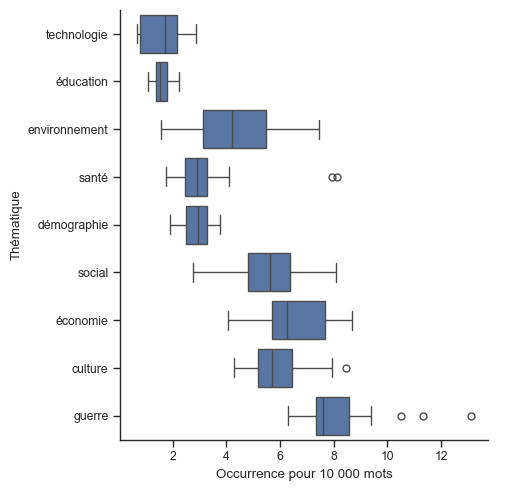

In [166]:
# Représentation graphique et sauvegarde
fig = sns.catplot(data= data_long, x="Occurrence pour 10 000 mots", y="Thématique", kind="box", order=data_long.sort_values("Occurrence pour 10 000 mots").Thématique)
fig.figure.savefig("C:/Users/.../anova.png", dpi=450)

In [167]:
# Test non paramétrique de Kruskal-Wallis, pour affiner la première analyse de variance
h_stat, p_kw = kruskal(*[data_long[data_long['Thématique']==t]['Occurrence pour 10 000 mots'] 
                          for t in data_long['Thématique'].unique()])
print(f"Kruskal-Wallis H: {h_stat:.2f}, p={p_kw:.4f}")

# La différence est encore plus marquée (H = 178,48)
# La p-value reste significative (p < 0,00001)

Kruskal-Wallis H: 178.48, p=0.0000


La thématique de la guerre tend à beaucoup apparaître en moyenne pour 10 000 mots, comparé aux autres thématiques analysées à nombre de mots égal. En outre, on peut affirmer que cette différence est significative (p = 4,64e-65, inférieur au seuil conventionnel 0,05). Cependant la variance inter-lexicale est suspectement élevée (F-value = 91,43, nettement supérieur au seuil conventionnel 3,5), indiquant qu’il faut prendre nos résultats avec précaution, même si les tests non paramétriques confirment la tendance (Kruskal-Wallis, H = 178,48). Il faut également noter que nos valeurs sont des moyennes, et donc que le lexique de la guerre n’apparaît pas nécessairement 8 fois pour 10 000 mots dans chaque discours. Si la guerre est une thématique qui apparaît significativement plus que les autres, l’ordre de grandeur mériterait donc d’être affiné. Enfin, le choix des mots pour les lexiques de nos thématiques peut être jugé trop arbitraire. Rien ne garantit la parfaite équivalence entre nos 10 mots de la guerre et nos 10 mots de la santé. Une meilleure analyse inclurait davantage de mots, ou bien contrôlerait l’ensemble des mots prononcés toutes choses égales par ailleurs. Nous nous en tiendrons donc à conclure ici que la guerre est un thème important dans les discours présidentiels français, qui tend à être plus présent que les autres thématiques ces 25 dernières années. L’hypothèse 1 d’importance générale de la guerre dans les discours présidentiels français est confirmée.

### **--> Analyse 3 : Score TF-IDF à travers le temps**

Notre deuxième hypothèse affirme que la guerre devient de plus en plus importante dans les discours présidentiels français depuis le 11 septembre 2001, et a priori depuis 2020. Un indicateur robuste pour mesurer le caractère saillant ou non d’un sujet est le score TF-IDF. Issu de l’anglais « term frequency-inverse document frequency », le TF-IDF mesure l’importance d’un terme contenu dans un document, relativement à une collection ou un corpus. Le score varie en fonction du nombre d’occurrence dans un document, rapporté au nombre de mots dans le document, ainsi que de la fréquence d’apparition du terme dans le reste du corpus. Un score élevé traduit à la fois une fréquence élevée dans le ou les documents, mais aussi un caractère saillant vis-à-vis du reste du corpus. Un autre indicateur pertinent aurait pu être le calcul des spécificités de Lafon. Cet indacteur permet lui aussi de quantifier l’importance d’un mot relativement au reste du corpus. Cependant, dans le cadre d’un apprentissage autonome, le TF-IDF s’est révélé comme l’indicateur le plus accessible et le plus enseigné dans les manuels de programmation. En outre, sa capacité à démontrer la saillance d’un mot au sein de larges corpus, fait de cet indicateur un outil adapté pour nos 5 521 discours. Afin d’améliorer l’analyse, nous avons étendu le lexique de la guerre à 20 mots au lieu de 10 : "guerre", "paix", "sécurité", "mobilisation", "réarmement", "armée", "conflit", "menace", "mobiliser", "défense", "front", "attaquer", "bataille", "attaque", "riposte", "déploiement", "stratégique", "tactique", "combattre", "combat". Le score mobilisé dans la figure 3 représente la valeur TF-IDF moyenne par discours de l’ensemble du lexique chaque année. Il indique une augmentation significative et élevée du score TF-IDF du lexique de la guerre au fil des années dans les discours présidentiels français.

In [168]:
# Importation du Dataframe score TF-IDF de la guerre
score = pd.read_csv("C:/Users/.../score.csv")
score.head()

,année,guerre,paix,sécurité,mobilisation,réarmement,armée,conflit,menace,mobiliser,...,attaquer,bataille,attaque,riposte,déploiement,stratégique,tactique,combattre,combat,tfidf_moyen
0,2001.0,0.009441,0.015928,0.012192,0.003755,0.000000,0.008290,0.009936,0.004945,0.004784,...,0.004381,0.002680,0.008800,0.009841,0.000817,0.001699,0.000000,0.006447,0.014442,0.006485
1,2002.0,0.005930,0.011263,0.016065,0.005864,0.000397,0.012207,0.005018,0.004470,0.005379,...,0.001373,0.001551,0.002786,0.000192,0.001040,0.002453,0.000213,0.004971,0.007746,0.005050
2,2003.0,0.008580,0.015056,0.011098,0.006222,0.000000,0.003748,0.007488,0.003837,0.004936,...,0.001608,0.000380,0.000402,0.000320,0.001166,0.002134,0.000865,0.002034,0.005139,0.004280
3,2004.0,0.004653,0.017516,0.009655,0.005823,0.000000,0.008002,0.005877,0.004315,0.006424,...,0.001932,0.001707,0.000520,0.000000,0.000743,0.003820,0.000166,0.003276,0.011101,0.004650
4,2005.0,0.003201,0.015836,0.008086,0.006194,0.000000,0.005342,0.004968,0.002607,0.006016,...,0.000916,0.001572,0.000536,0.000000,0.000316,0.004237,0.000333,0.004742,0.005427,0.003987


In [170]:
# Test de corrélation
pearsonr(score["année"], score["tfidf_moyen"])

# Il existe une corrélation forte entre le score TF-IDF du lexique de la guerre et le temps (r = 0,697)
# Cette relation est significative (p = 0,0001)
# Il y a donc une corrélation positive forte et significative entre le score TF-IDF et l'évolution du temps

PearsonRResult(statistic=np.float64(0.697085537743082), pvalue=np.float64(0.00010789039706677585))

L’analyse de la corrélation montre de manière générale qu’il y a une augmentation positive forte (r = 0,70 considéré comme forte en sciences politiques25) et significative (p-value < 0,0001) du score TF-IDF du lexique de la guerre à travers le temps. Cela prouve que la guerre est une thématique qui devient significativement importante dans les discours présidentiels français, a priori à partir de 2015, puis 2022 et 2025 (voir les représentations graphiques). Ces dates pourraient correspondre à des évènements marquants, comme les attentats terroristes qui ont touché le pays en 2015 et l’agression russe contre l’Ukraine en 2022. L’année 2025 pose question, étant donné le manque de recul concernant cette date à l’heure actuelle. L’hypothèse 2 d’importance croissante de la guerre est elle aussi confirmée.

### **--> Analyse 4 : Variance inter-cooccurrence**

Notre troisième hypothèse affirme que la guerre est de plus en plus associée à d’autres thématiques au fil du temps. Pour le vérifier nous allons réaliser un test de corrélation entre chaque catégorie de cooccurrence et le temps. Nous réaliserons également encore une fois une analyse de variance entre nos thématiques.

In [212]:
# A : Construction d'un tableau de cooccurrences pour chaque thématique en fonction du temps
tableau_corrélation_cooccurrence = pd.DataFrame()

# Calcul du coefficient de corrélation pour chaque cooccurrence thématique
tableau_corrélation_cooccurrence["économie"] = pearsonr(cooccurrence["année"], cooccurrence["économie"])
tableau_corrélation_cooccurrence["santé"] = pearsonr(cooccurrence["année"], cooccurrence["santé"])
tableau_corrélation_cooccurrence["éducation"] = pearsonr(cooccurrence["année"], cooccurrence["éducation"])
tableau_corrélation_cooccurrence["environnement"] = pearsonr(cooccurrence["année"], cooccurrence["environnement"])
tableau_corrélation_cooccurrence["technologie"] = pearsonr(cooccurrence["année"], cooccurrence["technologie"])
tableau_corrélation_cooccurrence["social"] = pearsonr(cooccurrence["année"], cooccurrence["social"])
tableau_corrélation_cooccurrence["démographie"] = pearsonr(cooccurrence["année"], cooccurrence["démographie"])
tableau_corrélation_cooccurrence["culture"] = pearsonr(cooccurrence["année"], cooccurrence["culture"])

# Présentation des résultats
tableau_corrélation_cooccurrence = tableau_corrélation_cooccurrence.sort_values(axis=1, by=0, ascending=False)
tableau_corrélation_cooccurrence.head()

# La technologie est la cooccurrence thématique dont la corrélation est la plus forte avec le temps (r = 0,86) et la plus significative (p = 2.410298e-08)
# Le social est la seule thématique dont la corrélation est non significative (p = 0,18)
# Il existe une corrélation positive forte et significative avec le temps pour presque l'ensemble des cooccurrences thématiques désignées

,technologie,démographie,éducation,économie,environnement,santé,culture,social
0,8.650931e-01,0.794482,0.702818,0.668205,0.663927,0.509440,0.440385,0.272876
1,2.410298e-08,0.000002,0.000089,0.000262,0.000296,0.009291,0.027581,0.186922


Le test des coefficients de corrélation démontre une hausse des cooccurrences de la guerre sur un ensemble de thématiques, avec une nuance pour le social. Les domaines de la technologie, de la démographie, de l’éducation, de l’économie et de l’environnement se démarquent par une corrélation positive forte (r > 0,65) et significative (p < 0,005). La technologie, la démographie et l’éducation observent les évolutions les plus importantes (respectivement r = 0,87, r = 0,79 et r = 0,70). Tout comme la figure 2, nos résultats sont très élevés et mériteraient d’être questionnés. La significativité très élevé de certaines corrélations peut être expliquée par le nombre de mots par lexiques (10) et le nombre d’individus observés (25 ans). Cela rend nos résultats sensibles aux valeurs aberrantes. Cependant, sur presque l’ensemble des lexiques, l’hypothèse 3 d’expansion de la guerre à d’autres thématiques reste tendanciellement confirmée.

Il reste maintenant à réaliser l'analyse de variance :

In [214]:
# B : Analyse de variance inter-cooccurrence
F, p = f_oneway(cooccurrence["économie"], cooccurrence["santé"], cooccurrence["éducation"], cooccurrence["environnement"], cooccurrence["technologie"], cooccurrence["social"], cooccurrence["démographie"], cooccurrence["culture"])
print(f"F - value: {F}")
print(f"p - value: {p}")

# Il existe des différences fortes entre les cooccurrences (F = 40,81)
# Les différences sont significatives (p = 7.974721005359653e-35)
# Étant donné la valeur élevée de la F-value, certaines précautions s'imposent dans l'interprétation des résultats

F - value: 40.813305970367736
p - value: 7.974721005359653e-35


In [215]:
# Préparation d'une représentation graphique, transformation des données au format long
thèmes = ["économie", "santé", "éducation", "environnement", "technologie", "social", "démographie", "culture"]
data_long = pd.DataFrame()

# Préparation des données
anova = pd.concat([occurrence_économie, occurrence_santé, occurrence_éducation, occurrence_environnement, occurrence_technologie, occurrence_social, occurrence_démographie, occurrence_culture], axis=1)
anova["occurrence_guerre"] = occurrence["somme"]
anova.columns = ["économie", "santé", "éducation", "environnement", "technologie", "social", "démographie", "culture", "guerre"]

In [216]:
# Création du format long
for thème in thèmes:
    # Créer un dataframe temporaire pour ce thème
    temp = pd.DataFrame({
        "Thématique": thème,
        "Cooccurrence": cooccurrence[thème]  # vos valeurs
    })
    # Ajouter au dataframe principal
    data_long = pd.concat([data_long, temp], ignore_index=True)

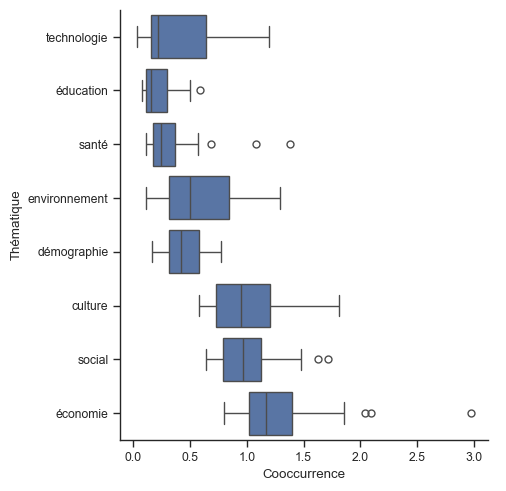

In [217]:
# Représentation graphique
fig = sns.catplot(data= data_long, x="Cooccurrence", y="Thématique", kind="box", order=data_long.sort_values("Cooccurrence").Thématique)
fig.figure.savefig("C:/Users/.../anova_cooccurrence.png", dpi=450)

In [220]:
# Test de variance non paramétrique (Kruskal-Wallis)
h_stat, p_kw = kruskal(*[data_long[data_long["Thématique"]==t]["Cooccurrence"] 
                          for t in data_long['Thématique'].unique()])
print(f"Kruskal-Wallis H: {h_stat:.2f}, p={p_kw:.4f}")

# Le test non paramétrique confirme les tendances
# Il existe des différences élevées entre les cooccurrences thématiques (H = 127,46)
# Ces différences sont significatives (p < 0,0001)

Kruskal-Wallis H: 127.46, p=0.0000


Alors que le social était la thématique qui évolue le moins avec le temps dans les figures 4 et 5 (voir les représentations graphiques), la figure 6 ci-dessus démontre qu’il s’agit en réalité d’une de celles qui cooccurrent en moyenne le plus avec la guerre (parmi les 8 lexiques étudiés), aux côtés de l’économie et la culture (évolution positive, modérée-forte, et significative pour ces deux thématiques). On remarquera une forte variance dans les domaines de la technologie, de l’environnement et de la culture. Plusieurs valeurs aberrantes apparaissent par ailleurs, rappelant des pics notables de cooccurrences observés temporellement (2020 pour la santé, 2002 pour le social…) mais sous-entendant aussi le caractère aberrant des certaines évolutions récentes du nombre de cooccurrences (2025 pour l’économie et le social). Le test de variance indique qu’il existe des différentes inter-thématiques significatives (p-value = 7,97e-35), mais encore une fois l’ordre de grandeur reste à préciser (F-value élevée = 40,81, confirmé par le test non paramétrique de Kruskal-Wallis H = 127,46). Enfin, on rappellera que nos valeurs sont des moyennes, signifiant qu’il n’y a pas nécessairement 1 coocurrence guerre/économie dans chaque discours. Les mêmes précautions que la figure 2 s’imposent. Le test permet cependant d’affiner l’hypothèse 3, en montrant quelles thématiques testées sont le plus associées à la guerre dans les discours présidentiels français (en l’occurrence l’économie, le social et la culture).

### **--> Analyse 5 : Cooccurrence à travers le temps**

Le dernier test statistique vise à déterminer la tendance générale des cooccurrences avec la guerre sur nos 8 thématiques. Il s’agit de la somme du nombre moyen de cooccurrences par discours chaque année sur l’ensemble des sujets étudiés.

In [210]:
# Importation des données
cooccurrence = pd.read_csv("C:/Users/.../cooccurrences.csv")
cooccurrence.tail()

,année,économie,santé,éducation,environnement,technologie,social,démographie,culture,somme
20,20,1.357724,1.081301,0.406504,0.707317,0.666667,1.097561,0.447154,1.227642,6.991870
21,21,1.396396,0.567568,0.378378,0.918919,0.810811,1.378378,0.513514,1.540541,7.504505
22,22,1.564706,0.370588,0.300000,0.858824,0.782353,0.811765,0.576471,1.005882,6.270588
23,23,2.040323,0.274194,0.233871,0.838710,1.193548,0.782258,0.596774,0.975806,6.935484
24,24,2.979592,0.680272,0.469388,1.292517,1.108844,1.625850,0.768707,1.333333,10.258503


In [211]:
# Coefficient de corrélation
pearsonr(cooccurrence["année"], cooccurrence["somme"])

# Coefficient de corrélation fort (r = 0,745)
# P-value significative (p = 1.8833908606278616e-05)
# Il existe une relation positive forte et significative entre la somme des cooccurrences et le temps

PearsonRResult(statistic=np.float64(0.7457006771010538), pvalue=np.float64(1.8833908606278616e-05))

La corrélation entre les cooccurrences et le temps est positive, forte (r = 0,75) et significative (p-value = 1,88e-05). L’ensemble de ces éléments montre une expansion générale de la guerre vers d’autres thématiques. L’hypothèse 3 d’expansion de la guerre vers d’autres thématiques est confirmée d’un point de vue général.

## **Conclusion**

À l’issue de nos résultats, nous sommes en mesure d’affirmer que la rhétorique de guerre est effectivement un sujet important dans les discours présidentiels français depuis le 11 septembre 2001. Cette importance est significativement croissante avec le temps et s’étend à de nouvelles thématiques. L’ensemble de ces éléments vont dans le sens de nos hypothèses et répondent sans ambiguïté à notre question initiale : il y a bien un glissement sémantique significatif chez les Présidents français depuis plusieurs années. Dans le cadre de nos réflexions théoriques, cela reflète la capacité de la guerre à cadrer cognitivement les discours, en investissant des thématiques vides comme l’économie ou la culture. En outre, nous sommes en mesure d’identifier plusieurs dates clés potentielles. L’importance croissante de la guerre peut s’observer à partir de 2015, et accélère en 2022 puis en 2024-2025. Ces dates pourraient correspondre aux attaques terroristes qu’a subi la France en 2015, à l’agression russe contre l’Ukraine en 2022 et à la hausse des tensions internationales depuis quelques années. La pénétration de la guerre vers d’autres thématiques semble suivre sa prise d’importance, avec quelques années de délai : 2017-2018 puis 2025.

Cependant, ce travail se confronte à quelques limites. La plupart de nos analyses reposent sur la construction de lexiques thématiques à la fois limités (10 à 20 mots) et discutables (choix des mots difficile à objectiver à ce stade de la réflexion). Cela se traduit dans nos tests statistiques, donnant lieu à plusieurs valeurs aberrantes (valeur des F-values suspectes). Nos résultats représentent davantage des tendances que des valeurs absolues.

À ce titre, un travail plus poussé pourrait combler nos lacunes. D’emblée on pourrait imaginer le recours à des lexiques plus étendus et donc moins sensibles aux valeurs aberrantes. Une autre piste semble également être le recours à des méthodes plus poussées de traitement automatique du langage. Ainsi, le recours à des indicateurs appropriés pour mesurer la cooccurrence serait une première avancée. Il en existe deux : le t-score et l’information mutuelle. Ils permettent de rapporter la cooccurrence à l’occurrence isolée de chacun des mots. On pourrait alors rendre la mesure plus robuste. Parmi toutes ces propositions, c’est surtout l’analyse de la poly-cooccurrence qui semble fondamentale pour la poursuite de cette recherche. Plutôt que d’analyser la guerre mot par mot ou bien lexique par lexique, il existe des méthodes pouvant mesurer les relations complexes de cooccurrences toutes choses égales par ailleurs. Par exemple, les analyses de réseau permettent d’observer directement l’ensemble des cooccurrences d’un mot. Cela fournit des indicateurs supplémentaires qui pourraient enrichir la recherche dans une large mesure. On pourrait alors mesurer la centralité de la guerre dans le réseau de cooccurrence, déterminer les sujets cooccurrents les plus proches par l’identification de clusters, et voir les chemins discursifs les plus courts menant la guerre vers d’autres sujets. Cette approche a été notamment développée sous le nom de « cooccurrence généralisée » par Viprey, ayant lui-même travaillé sur des discours présidentiels avec Damon Mayaffre. Selon l’avancée de l’analyse de réseau, l’utilisation du deep learning pourrait également être intéressante en dernière partie. Cela permettrait d’identifier des chemins de cooccurrence inter-thématiques privilégiés, prédire de nouvelles associations, et construire des « discours de guerre » futurs sur ces thématiques. L’ensemble de ces méthodes pourraient renforcer notre cadre théorique, en prouvant la capacité de cadrage cognitif de la guerre.